# Running the FlyWire Drosophila SONATA Circuit with NEST

This notebook demonstrates how to:
1. Load a SONATA circuit converted from the FlyWire v783 Drosophila connectome
2. Build the network in **NEST GPU** (fast, requires GPU) or **standard NEST** (CPU fallback)
3. Run the simulation with Poisson input stimulation
4. Visualize spike raster plots and firing rate distributions

**Prerequisites:**
- Run `convert_to_sonata.py` first to generate the SONATA circuit files
- Either `nestgpu` (GPU) or `nest` (CPU) Python package installed

```bash
python convert_to_sonata.py --data-dir ../../fly-brain/data --output-dir ./sonata_circuit
```

In [1]:
import json
from pathlib import Path
from time import perf_counter

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CIRCUIT_DIR = Path("./sonata_circuit")
assert CIRCUIT_DIR.exists(), (
    f"SONATA circuit not found at {CIRCUIT_DIR}. "
    "Run convert_to_sonata.py first."
)

## 1. Load SONATA Circuit Data

Read the SONATA HDF5 files to extract neuron count, synaptic connectivity, and experiment configuration.

In [2]:
def load_sonata_circuit(circuit_dir: Path) -> dict:
    """Load all SONATA circuit data from HDF5 files into a dict."""
    net = circuit_dir / "network"
    data = {}

    # -- Load configs --
    with open(circuit_dir / "circuit_config.json") as f:
        data["circuit_config"] = json.load(f)
    with open(circuit_dir / "simulation_config.json") as f:
        data["sim_config"] = json.load(f)
    with open(circuit_dir / "node_sets.json") as f:
        data["node_sets"] = json.load(f)

    # -- Internal nodes --
    with h5py.File(net / "internal_nodes.h5", "r") as f:
        pop = f["nodes/internal"]
        data["n_neurons"] = len(pop["node_id"])
        data["flywire_ids"] = pop["0/flywire_id"][:]

    # -- Internal edges --
    with h5py.File(net / "internal_internal_edges.h5", "r") as f:
        pop = f["edges/internal_to_internal"]
        data["pre_idx"] = pop["source_node_id"][:].astype(np.int64)
        data["post_idx"] = pop["target_node_id"][:].astype(np.int64)
        data["weights"] = pop["0/syn_weight"][:]
        data["delays"] = pop["0/delay"][:]

    # -- External edges (Poisson input targets) --
    with h5py.File(net / "external_internal_edges.h5", "r") as f:
        pop = f["edges/external_to_internal"]
        data["stim_targets"] = pop["target_node_id"][:].astype(np.int64)
        data["stim_weights"] = pop["0/syn_weight"][:]
        data["stim_delays"] = pop["0/delay"][:]

    # -- Neuron dynamics params --
    params_path = circuit_dir / "components" / "cell_models" / "flywire_lif.json"
    with open(params_path) as f:
        data["neuron_params"] = json.load(f)

    # -- Simulation parameters --
    data["duration_ms"] = data["sim_config"]["run"]["tstop"]
    data["dt"] = data["sim_config"]["run"]["dt"]

    return data


t0 = perf_counter()
circuit = load_sonata_circuit(CIRCUIT_DIR)
print(f"Loaded in {perf_counter() - t0:.1f}s")
print(f"  Neurons:           {circuit['n_neurons']:,}")
print(f"  Synaptic edges:    {len(circuit['weights']):,}")
print(f"  Stimulated neurons: {len(circuit['stim_targets'])}")
print(f"  Simulation:        {circuit['duration_ms']} ms at dt={circuit['dt']} ms")

Loaded in 0.1s
  Neurons:           138,639
  Synaptic edges:    15,091,983
  Stimulated neurons: 2
  Simulation:        5000.0 ms at dt=0.1 ms


## 2. Build and Simulate

Auto-detects the available backend:
- **NEST GPU** (`nestgpu`): Uses `user_m1` custom neuron, native `poisson_generator`. Cannot reset state within a process.
- **Standard NEST** (`nest`): Uses `iaf_psc_alpha`, native `poisson_generator`. Runs on CPU.

In [3]:
# ---- Auto-detect backend ----
BACKEND = None
try:
    import nestgpu as ngpu
    BACKEND = "nestgpu"
    print("Backend: NEST GPU")
except ImportError:
    pass

if BACKEND is None:
    try:
        import nest
        BACKEND = "nest"
        print("Backend: Standard NEST (CPU)")
    except ImportError:
        raise ImportError(
            "Neither 'nestgpu' nor 'nest' is installed. "
            "Install one of them to run simulations."
        )

# ---- Parameters from SONATA circuit ----
p = circuit["neuron_params"]
SIM_DURATION_MS = circuit["duration_ms"]
STIM_RATE = circuit["sim_config"].get("metadata", {}).get("stim_rate_hz", 200.0)
N_MAX_SPIKE_TIMES = 4000 if SIM_DURATION_MS <= 10_000 else 15000

print(f"Neurons: {circuit['n_neurons']:,}, Edges: {len(circuit['weights']):,}")
print(f"Stimulated: {len(circuit['stim_targets'])} neurons at {STIM_RATE} Hz")
print(f"Duration: {SIM_DURATION_MS} ms")


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Oct  2 2025 07:05:42

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

Backend: Standard NEST (CPU)
Neurons: 138,639, Edges: 15,091,983
Stimulated: 2 neurons at 100.0 Hz
Duration: 5000.0 ms


### Build network, connect synapses, attach Poisson input, and simulate

In [4]:
stim_targets = circuit["stim_targets"].tolist()
stim_weight = float(circuit["stim_weights"][0])
stim_delay = float(circuit["stim_delays"][0])
delay = float(circuit["delays"][0])

t0 = perf_counter()

if BACKEND == "nestgpu":
    # ---- NEST GPU path ----
    NEURON_MODEL = "user_m1"

    neu = ngpu.Create(NEURON_MODEL, circuit["n_neurons"])
    if NEURON_MODEL == "user_m1":
        ngpu.SetStatus(neu, {
            "v_m": p["E_L"], "g_m": 0.0,
            "ref_on": 1, "slnc_on": 0,
            "v_0": p["E_L"], "v_rst": p["V_reset"],
            "v_th": p["V_th"], "tau_mbr": p["tau_m"],
            "tau_g": p["tau_syn_ex"], "t_ref": p["t_ref"],
        })
    else:
        ngpu.SetStatus(neu, {
            "V_m": p["E_L"], "E_L": p["E_L"], "V_th": p["V_th"],
            "V_reset": p["V_reset"], "C_m": p["C_m"], "tau_m": p["tau_m"],
            "tau_syn_ex": p["tau_syn_ex"], "tau_syn_in": p["tau_syn_in"],
            "t_ref": p["t_ref"], "I_e": p["I_e"],
        })
    print(f"  Neurons created in {perf_counter() - t0:.2f}s")

    t1 = perf_counter()
    ngpu.Connect(
        circuit["pre_idx"].tolist(), circuit["post_idx"].tolist(),
        {"rule": "one_to_one"},
        {"weight": {"array": circuit["weights"].tolist()}, "delay": delay, "receptor": 0},
    )
    print(f"  Synapses connected in {perf_counter() - t1:.2f}s")

    t2 = perf_counter()
    pois = ngpu.Create("poisson_generator", len(stim_targets))
    ngpu.SetStatus(pois, {"rate": STIM_RATE})
    i_poi = list(range(pois.i0, pois.i0 + pois.n))
    ngpu.Connect(i_poi, stim_targets, {"rule": "one_to_one"},
                 {"receptor": 1, "delay": stim_delay, "weight": stim_weight})
    if NEURON_MODEL == "user_m1":
        for idx in stim_targets:
            ngpu.SetStatus([idx], {"ref_on": 0})
    print(f"  Poisson input connected in {perf_counter() - t2:.2f}s")

    # Simulate
    ngpu.ActivateRecSpikeTimes(neu, N_MAX_SPIKE_TIMES)
    print(f"\nSimulating {SIM_DURATION_MS} ms...")
    t_sim = perf_counter()
    ngpu.Simulate(SIM_DURATION_MS)
    sim_time = perf_counter() - t_sim
    print(f"Simulation: {sim_time:.2f}s  (realtime ratio: {SIM_DURATION_MS / 1000 / sim_time:.3f}x)")

    # Retrieve spikes
    spike_trains = ngpu.GetRecSpikeTimes(neu)
    spike_times_list, spike_ids_list = [], []
    for nidx, times in enumerate(spike_trains):
        if len(times) > 0:
            spike_times_list.append(np.array(times))
            spike_ids_list.append(np.full(len(times), nidx, dtype=np.int64))

else:
    # ---- Standard NEST path ----
    nest.ResetKernel()
    nest.resolution = 0.1

    neurons = nest.Create("iaf_psc_alpha", circuit["n_neurons"], params={
        "V_m": p["E_L"], "E_L": p["E_L"], "V_th": p["V_th"],
        "V_reset": p["V_reset"], "C_m": p["C_m"], "tau_m": p["tau_m"],
        "tau_syn_ex": p["tau_syn_ex"], "tau_syn_in": p["tau_syn_in"],
        "t_ref": p["t_ref"], "I_e": p["I_e"],
    })
    print(f"  Neurons created in {perf_counter() - t0:.2f}s")

    # Connect synapses — group by source neuron because
    # NodeCollections require unique, sorted IDs
    t1 = perf_counter()
    min_gid = neurons[0].global_id
    pre_gids = circuit["pre_idx"] + min_gid
    post_gids = circuit["post_idx"] + min_gid
    weights_arr = circuit["weights"]

    # Sort edges by (source, target) so each group's targets are ascending
    sort_order = np.lexsort((post_gids, pre_gids))
    sorted_pre = pre_gids[sort_order]
    sorted_post = post_gids[sort_order]
    sorted_w = weights_arr[sort_order]

    unique_src, src_counts = np.unique(sorted_pre, return_counts=True)
    offsets = np.concatenate([[0], np.cumsum(src_counts)])

    for i in range(len(unique_src)):
        s, e = int(offsets[i]), int(offsets[i + 1])
        tgt_ids = sorted_post[s:e]
        w_vals = sorted_w[s:e]
        src_nc = nest.NodeCollection([int(unique_src[i])])

        if len(np.unique(tgt_ids)) == len(tgt_ids):
            # No duplicate targets — bulk connect
            tgt_nc = nest.NodeCollection(tgt_ids.tolist())
            nest.Connect(src_nc, tgt_nc, "all_to_all",
                         syn_spec={"weight": w_vals.reshape(-1, 1).tolist(),
                                   "delay": delay})
        else:
            # Multapses present — connect each edge individually
            for t, w in zip(tgt_ids, w_vals):
                nest.Connect(src_nc, nest.NodeCollection([int(t)]),
                             syn_spec={"weight": float(w), "delay": delay})
    print(f"  Synapses connected in {perf_counter() - t1:.2f}s")

    # Poisson input
    t2 = perf_counter()
    stim_nc = neurons[stim_targets]
    pg = nest.Create("poisson_generator", len(stim_targets), params={"rate": STIM_RATE})
    nest.Connect(pg, stim_nc, "one_to_one",
                 syn_spec={"weight": stim_weight, "delay": stim_delay})
    print(f"  Poisson input connected in {perf_counter() - t2:.2f}s")

    # Spike recorder
    sr = nest.Create("spike_recorder")
    nest.Connect(neurons, sr)

    # Simulate
    print(f"\nSimulating {SIM_DURATION_MS} ms...")
    t_sim = perf_counter()
    nest.Simulate(SIM_DURATION_MS)
    sim_time = perf_counter() - t_sim
    print(f"Simulation: {sim_time:.2f}s  (realtime ratio: {SIM_DURATION_MS / 1000 / sim_time:.3f}x)")

    # Retrieve spikes and convert senders to 0-based indices
    events = sr.get("events")
    raw_ids = events["senders"]
    min_gid = neurons[0].global_id
    spike_ids_0based = raw_ids - min_gid

    # Build per-neuron spike trains for downstream analysis
    spike_trains = [[] for _ in range(circuit["n_neurons"])]
    for t_ms, nidx in zip(events["times"], spike_ids_0based):
        spike_trains[nidx].append(t_ms)
    spike_trains = [np.array(s) for s in spike_trains]

    spike_times_list, spike_ids_list = [], []
    for nidx, times in enumerate(spike_trains):
        if len(times) > 0:
            spike_times_list.append(times)
            spike_ids_list.append(np.full(len(times), nidx, dtype=np.int64))

# ---- Unified output ----
spike_times = np.concatenate(spike_times_list) if spike_times_list else np.array([])
spike_ids = np.concatenate(spike_ids_list) if spike_ids_list else np.array([], dtype=np.int64)
n_total_spikes = len(spike_times)
n_active = sum(1 for t in spike_trains if len(t) > 0)

print(f"\nResults:")
print(f"  Total spikes:   {n_total_spikes:,}")
print(f"  Active neurons: {n_active:,} / {circuit['n_neurons']:,} "
      f"({100 * n_active / circuit['n_neurons']:.1f}%)")
print(f"  Total time:     {perf_counter() - t0:.2f}s")


Mar 30 00:24:34 SimulationManager::set_status [Info]: 
    Tem  Neurons created in 0.03s
poral resolution changed from 0.1 to 0.1 ms.
  Synapses connected in 28.80s
  Poisson input connected in 0.00s

Simulating 5000.0 ms...

Mar 30 00:25:04 NodeManager::prepare_nodes [Info]: 
    PrSimulation: 283.23s  (realtime ratio: 0.018x)
eparing 138642 nodes for simulation.

Mar 30 00:25:04 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 138642
    Simulation time (ms): 5000
    Number of OpenMP threads: 1
    Not using MPI

Mar 30 00:29:47 SimulationManager::run [Info]: 
    Simulation finished.

Results:
  Total spikes:   18,278,749
  Active neurons: 33,953 / 138,639 (24.5%)
  Total time:     316.17s


## 4. Save Results in SONATA Spikes Format

Write output spikes to the SONATA-standard HDF5 format for interoperability.

In [5]:
output_dir = CIRCUIT_DIR / "output"
output_dir.mkdir(exist_ok=True)
spikes_path = output_dir / "spikes.h5"

# Sort by time for SONATA compliance
sort_idx = np.argsort(spike_times)
sorted_times = spike_times[sort_idx]
sorted_ids = spike_ids[sort_idx]

with h5py.File(spikes_path, "w") as f:
    pop = f.create_group("spikes/internal")
    ds = pop.create_dataset("timestamps", data=sorted_times)
    ds.attrs["units"] = "ms"
    pop.create_dataset("node_ids", data=sorted_ids.astype(np.uint64))
    pop.attrs["sorting"] = "by_time"

print(f"Spikes saved to {spikes_path}")
print(f"  {len(sorted_times):,} spikes from {n_active:,} neurons")

Spikes saved to sonata_circuit/output/spikes.h5
  18,278,749 spikes from 33,953 neurons


## 5. Visualize Results

### 5a. Spike Raster Plot

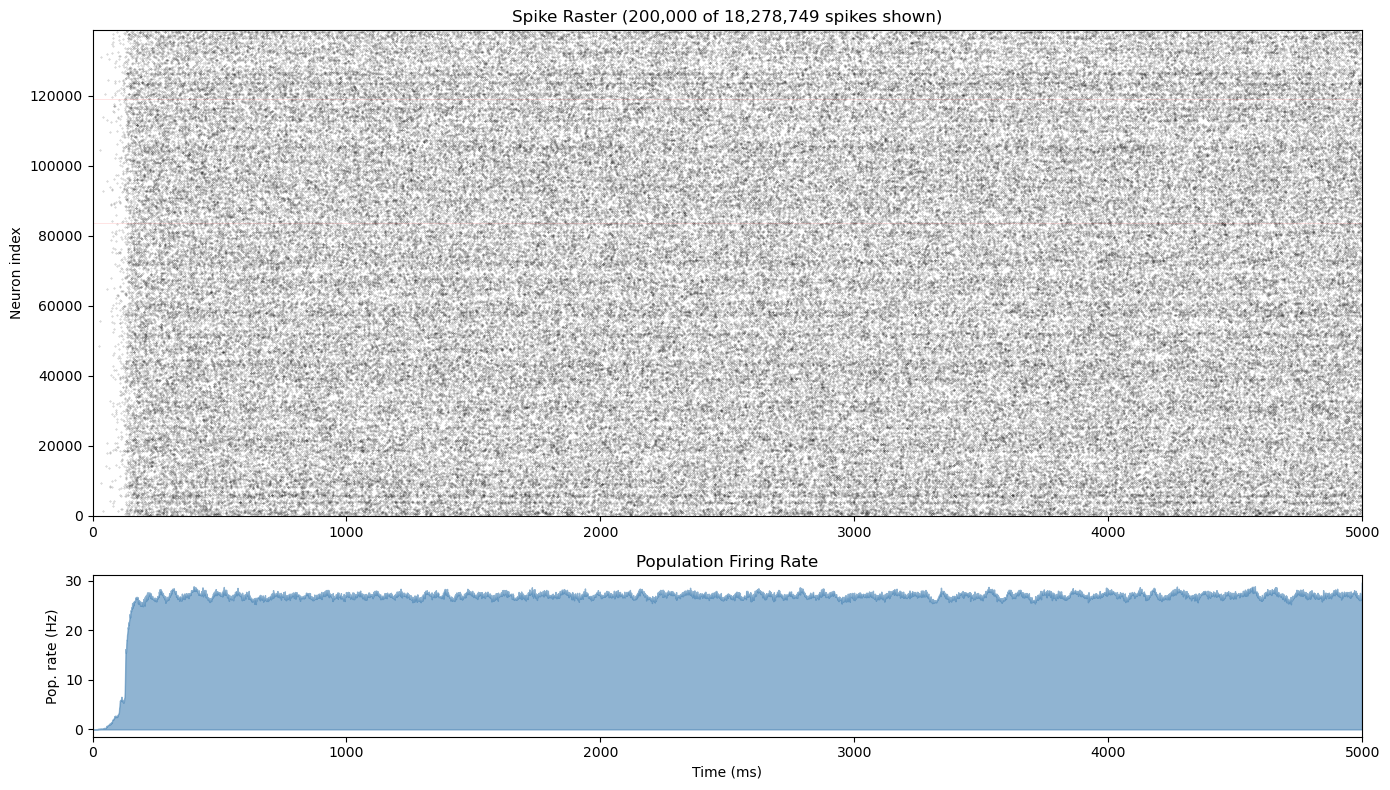

Saved to sonata_circuit/output/raster_plot.png


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [3, 1]})

# Raster plot (subsample for readability)
ax = axes[0]
max_points = 200_000
if len(spike_times) > max_points:
    idx = np.random.default_rng(0).choice(len(spike_times), max_points, replace=False)
    ax.scatter(spike_times[idx], spike_ids[idx], s=0.1, alpha=0.3, c="k", rasterized=True)
    ax.set_title(f"Spike Raster ({max_points:,} of {len(spike_times):,} spikes shown)")
else:
    ax.scatter(spike_times, spike_ids, s=0.1, alpha=0.3, c="k", rasterized=True)
    ax.set_title(f"Spike Raster ({len(spike_times):,} spikes)")

# Highlight stimulated neurons
for stim_idx in circuit["stim_targets"]:
    ax.axhline(y=stim_idx, color="red", alpha=0.15, linewidth=0.5)

ax.set_ylabel("Neuron index")
ax.set_xlim(0, SIM_DURATION_MS)
ax.set_ylim(-0.5, circuit["n_neurons"])

# Population firing rate histogram (1 ms bins)
ax2 = axes[1]
bin_width = 1.0  # ms
bins = np.arange(0, SIM_DURATION_MS + bin_width, bin_width)
counts, _ = np.histogram(spike_times, bins=bins)
rate_hz = counts / (bin_width / 1000) / circuit["n_neurons"]
ax2.fill_between(bins[:-1], rate_hz, alpha=0.6, color="steelblue")
ax2.set_xlabel("Time (ms)")
ax2.set_ylabel("Pop. rate (Hz)")
ax2.set_xlim(0, SIM_DURATION_MS)
ax2.set_title("Population Firing Rate")

plt.tight_layout()
plt.savefig(output_dir / "raster_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {output_dir / 'raster_plot.png'}")

### 5b. Per-Neuron Firing Rate Distribution

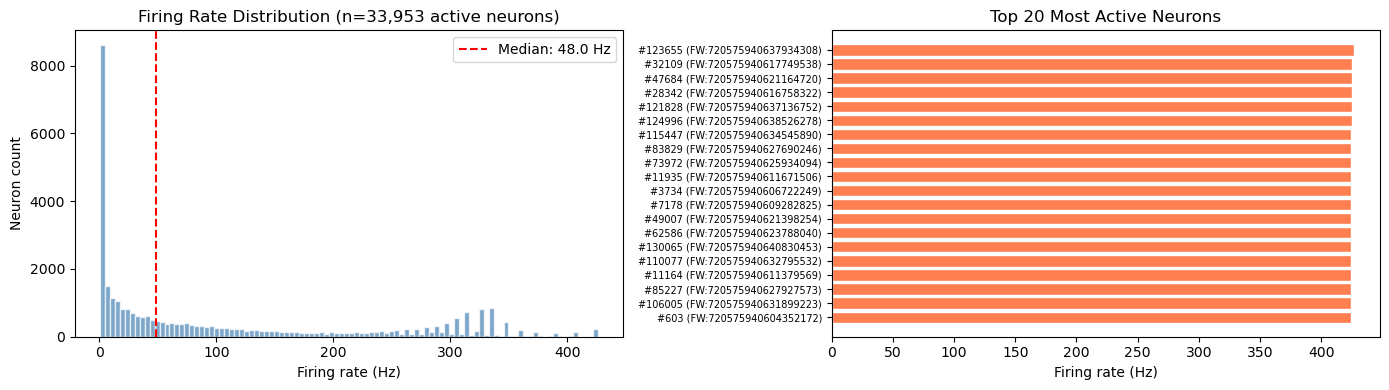


Firing rate stats (active neurons):
  Mean:   107.67 Hz
  Median: 48.00 Hz
  Max:    426.60 Hz
  Std:    123.54 Hz


In [8]:
# Compute per-neuron firing rates
duration_s = SIM_DURATION_MS / 1000.0
spike_counts = np.array([len(t) for t in spike_trains])
firing_rates = spike_counts / duration_s

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram of firing rates (active neurons only)
active_rates = firing_rates[firing_rates > 0]
ax = axes[0]
ax.hist(active_rates, bins=100, color="steelblue", alpha=0.7, edgecolor="white")
ax.set_xlabel("Firing rate (Hz)")
ax.set_ylabel("Neuron count")
ax.set_title(f"Firing Rate Distribution (n={len(active_rates):,} active neurons)")
ax.axvline(np.median(active_rates), color="red", linestyle="--",
           label=f"Median: {np.median(active_rates):.1f} Hz")
ax.legend()

# Top 20 most active neurons
ax2 = axes[1]
top_k = 20
top_idx = np.argsort(firing_rates)[-top_k:][::-1]
top_rates = firing_rates[top_idx]
top_flywire = circuit["flywire_ids"][top_idx]

bars = ax2.barh(range(top_k), top_rates, color="coral", edgecolor="white")
ax2.set_yticks(range(top_k))
ax2.set_yticklabels([f"#{i} (FW:{fid})" for i, fid in zip(top_idx, top_flywire)],
                     fontsize=7)
ax2.set_xlabel("Firing rate (Hz)")
ax2.set_title(f"Top {top_k} Most Active Neurons")
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig(output_dir / "firing_rates.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nFiring rate stats (active neurons):")
print(f"  Mean:   {np.mean(active_rates):.2f} Hz")
print(f"  Median: {np.median(active_rates):.2f} Hz")
print(f"  Max:    {np.max(active_rates):.2f} Hz")
print(f"  Std:    {np.std(active_rates):.2f} Hz")